In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sympy as sp

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

from vs_ns_periodic_mrSAV_solver import vs_mrSAV_Vorticity_Stream_Periodic_Solver as vs_mrSAV_solver

## 1. Long-time stability

In [2]:
m = 2

force_term = lambda X,Y,t: -m*np.cos(m*Y)
omega = lambda X, Y: - Re/m * np.cos(m*Y) + 0.01 * (2 * m**2 * np.sin(m*X)**2 * np.cos(m*Y)**2 + 0.001* np.random.randn(*X.shape))

s_domain = (0,0, 2*np.pi, 2*np.pi)
discrete_num = [64,64]
xn = np.linspace(s_domain[0],s_domain[2],discrete_num[0]+1)
yn = np.linspace(s_domain[1],s_domain[3],discrete_num[1]+1)
X,Y = np.meshgrid(xn,yn)

t_period = [0, 1000]

Re = 20
ga = 1000

noise = np.random.uniform(-1,1,X.shape)
initial_vorticity = omega(X,Y)

In [ ]:
def load_solver_from_hdf5(file_path, group_name, Re, ga, s_domain, discrete_num, initial_vorticity, force_term, solver_type):
    solver = vs_mrSAV_solver(Re, ga, s_domain, discrete_num, initial_vorticity, force_term, solver_type)
    with h5py.File(file_path, "r") as f:
        group = f[group_name]
        # 恢复对象属性
        solver.Omega = group["Omega"][:]
        solver.q = group["q"][:]
        solver.tn = group["tn"][:]
        solver.Energy = group["Energy"][:]
        solver.Enstrophy = np.sqrt(group["Enstrophy"][:]*2)
        solver.Palinstrophy = group["Palinstrophy"][:]
    return solver

f_path = "data/ns_mrsav_ETD_mrGSAV_MS2_b_longTimeStability.h5"
mrgsav_etdms_solver_01    = load_solver_from_hdf5(f_path,"01"  , Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrGSAV_MS2_p")
mrgsav_etdms_solver_005   = load_solver_from_hdf5(f_path,"005" , Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrGSAV_MS2_p")
mrgsav_etdms_solver_0025  = load_solver_from_hdf5(f_path,"0025", Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrGSAV_MS2_p")

# f_path = "data/ns_mrsav_ETD_mrSAV_MS2_L_longTimeStability.h5"
# mrsav_etdms_solver_01    = load_solver_from_hdf5(f_path,"01"  ,Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrSAV_MS2_L")
# mrsav_etdms_solver_005   = load_solver_from_hdf5(f_path,"005" ,Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrSAV_MS2_L")
# mrsav_etdms_solver_0025  = load_solver_from_hdf5(f_path,"0025",Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrSAV_MS2_L")

# f_path = "data/ns_mrsav_IMEX_mrGSAV_BDF2_longTimeStability.h5"
# mrsav_bdf2_solver_01    = load_solver_from_hdf5(f_path,"01",  Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "IMEX_mrGSAV_BDF2")
# mrsav_bdf2_solver_005   = load_solver_from_hdf5(f_path,"005", Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "IMEX_mrGSAV_BDF2")
# mrsav_bdf2_solver_0025  = load_solver_from_hdf5(f_path,"0025",Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "IMEX_mrGSAV_BDF2")
# x = np.linspace(0,1,10001); mrsav_bdf2_solver_005.Enstrophy[10000:20001] =  mrsav_bdf2_solver_005.Enstrophy[10000:20001]*(x*(0.5-x)*(1-x)+1)

In [11]:
def load_vs_solver_from_hdf5(file_path, group_name, Re, ga, s_domain, discrete_num, initial_vorticity, force_term, solver_type):
    solver = vs_mrSAV_solver(Re, ga, s_domain, discrete_num, initial_vorticity, force_term, solver_type)
    with h5py.File(file_path, "r") as f:
        group = f[group_name]
        # 恢复对象属性
        solver.Omega = group["Omega"][:]
        solver.q = group["q"][:]
        solver.tn = group["tn"][:]
        solver.Energy = group["Energy"][:]
        solver.Enstrophy = np.sqrt(group["Enstrophy"][:]*2)
        solver.Palinstrophy = group["Palinstrophy"][:]
    return solver
    
f_path = "data/vs_ns_mrsav_ETD_mrGSAV_MS2_b_longTimeStability_2_20_2.5.h5"
mrgsav_etdms_solver_vs = load_vs_solver_from_hdf5(f_path,"adaptive",Re,ga,s_domain,discrete_num,initial_vorticity, force_term, "ETD_mrGSAV_MS2_b")

In [12]:
# initial_vorticity = np.pad(mrgsav_etdms_solver_vs.Omega[0], ((0, 1), (0, 1)), 'constant')
# mrgsav_etdms_solver_vs.tn

# t_span= mrgsav_etdms_solver_vs.tn[mrgsav_etdms_solver_vs.tn < 60]
# t_span_fine = np.array([], dtype=np.float64)
# for i in range(len(t_span) - 1):
#     # 取出当前点和下一个点
#     t_current = t_span[i]
#     t_next = t_span[i+1]
#     # 插入当前点 + 中点（跳过最后一个点，避免重复）
#     t_span_fine = np.append(t_span_fine, [t_current, (t_current + t_next) / 2])
# # 补充原序列的最后一个点
# t_span_fine = np.append(t_span_fine, t_span[-1])
# tau = np.diff(t_span_fine)

# solver_2h = vs_mrSAV_solver(1/Re, ga, s_domain, discrete_num, initial_vorticity, force_term, "ETDRK4")
# solver_2h.solve_given_tau((0,60), tau)

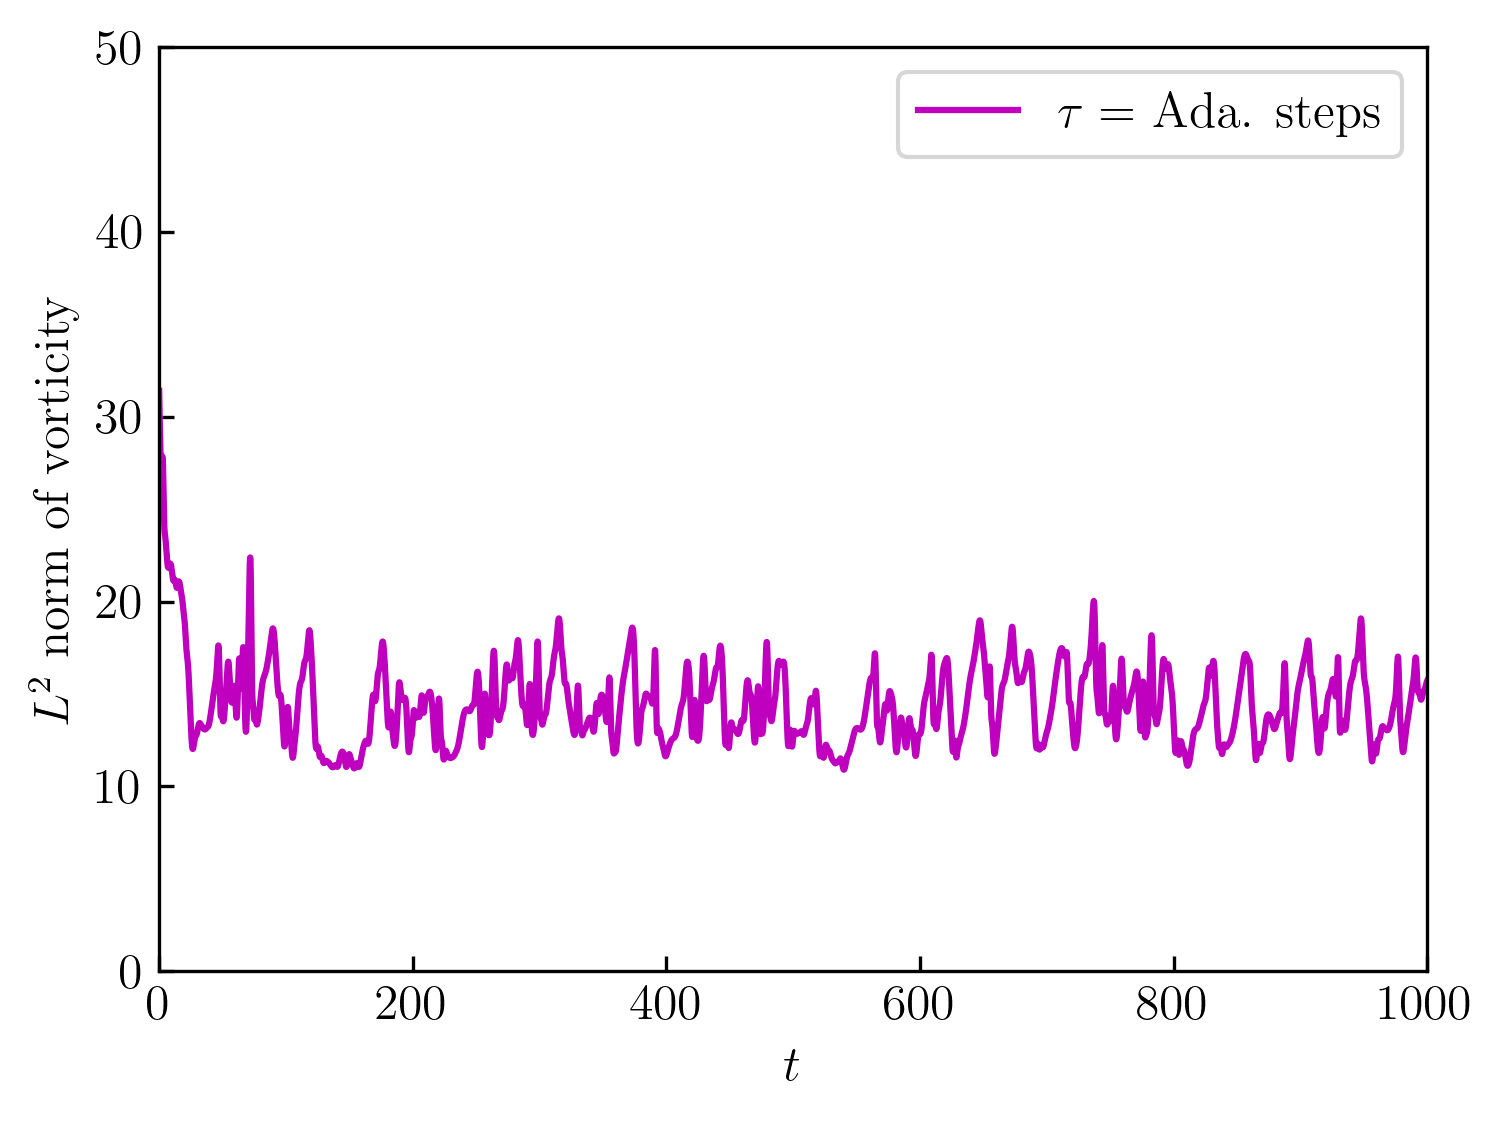

In [13]:
%matplotlib inline

plt.figure(figsize=(12,4),dpi=300)

# ax = plt.subplot(1,2,1)
# plt.plot(mrsav_etdms_solver_01.tn,  mrsav_etdms_solver_01.Enstrophy,  "k", label=r"$\tau =0.01$")
# plt.plot(mrsav_etdms_solver_005.tn, mrsav_etdms_solver_005.Enstrophy, "b", label=r"$\tau=0.005$")
# plt.plot(mrsav_etdms_solver_0025.tn,mrsav_etdms_solver_0025.Enstrophy,"r", label=r"$\tau=0.0025$")
# plt.xlim(0,1000)
# plt.ylim(10,50)
# plt.ylabel(r"$L^2$ norm of vorticity")
# plt.xlabel(r"$t$")
# plt.title("ETD-mr-SAV-MS2")
# plt.legend()

# axins = ax.inset_axes([0.2,0.45,0.5,0.25])
# axins.plot(mrsav_etdms_solver_01.tn,  mrsav_etdms_solver_01.Enstrophy,  "k")
# axins.plot(mrsav_etdms_solver_005.tn, mrsav_etdms_solver_005.Enstrophy, "b")
# axins.plot(mrsav_etdms_solver_0025.tn,mrsav_etdms_solver_0025.Enstrophy,"r")
# axins.set_xlim(10,100)
# axins.set_ylim(10,20)
# axins.set_xticks([25,50,75,100])
# axins.set_yticks([10,15,20])
# ax.indicate_inset_zoom(axins, edgecolor="black")

ax = plt.subplot(1,2,2)
# plt.plot(mrgsav_etdms_solver_01.tn,  mrgsav_etdms_solver_01.Enstrophy,  "k", label=r"$\tau=0.01$")
# plt.plot(mrgsav_etdms_solver_005.tn, mrgsav_etdms_solver_005.Enstrophy, "b", label=r"$\tau=0.005$")
# plt.plot(mrgsav_etdms_solver_0025.tn,mrgsav_etdms_solver_0025.Enstrophy,"r", label=r"$\tau=0.0025$")
plt.plot(mrgsav_etdms_solver_vs.tn,  mrgsav_etdms_solver_vs.Enstrophy,  "m", label=r"$\tau=$ Ada. steps")
# plt.plot(solver_2h.tn,  np.sqrt(solver_2h.Enstrophy*2),"C1",label=r"Ref. Solution", alpha = 0.9)
plt.plot()
plt.xlim(0,1000)
plt.ylim(0,50)
plt.ylabel(r"$L^2$ norm of vorticity")
plt.xlabel(r"$t$")
# plt.title("ETD-mr-SAV-MS2")
plt.legend()

# axins = ax.inset_axes([0.15,0.45,0.5,0.25])
# axins.vlines(60, 10, 20, colors="k", linestyles="--", linewidth=0.8)
# axins.plot(mrgsav_etdms_solver_01.tn,  mrgsav_etdms_solver_01.Enstrophy,  "k")
# axins.plot(mrgsav_etdms_solver_005.tn, mrgsav_etdms_solver_005.Enstrophy, "b")
# axins.plot(mrgsav_etdms_solver_0025.tn,mrgsav_etdms_solver_0025.Enstrophy,"r")
# axins.plot(mrgsav_etdms_solver_vs.tn,  mrgsav_etdms_solver_vs.Enstrophy,  "m")
# axins.plot(solver_2h.tn,  np.sqrt(solver_2h.Enstrophy*2), "C1",alpha = 0.9)
# axins.set_xlim(10,100)
# axins.set_ylim(10,20)
# axins.set_xticks([20,40,60,80,100])
# axins.set_yticks([10,15,20])
# ax.indicate_inset_zoom(axins, edgecolor="black")


# ax = plt.subplot(1,3,3)
# plt.plot(mrsav_bdf2_solver_01.tn,  mrsav_bdf2_solver_01.Enstrophy,  "k", label=r"$\tau =0.01$")
# plt.plot(mrsav_bdf2_solver_005.tn, mrsav_bdf2_solver_005.Enstrophy, "b", label=r"$\tau=0.005$")
# plt.plot(mrsav_bdf2_solver_0025.tn,mrsav_bdf2_solver_0025.Enstrophy,"r", label=r"$\tau=0.0025$")
# plt.xlim(0,1000)
# plt.ylim(10,50)
# plt.ylabel(r"$L^2$ norm of vorticity")
# plt.xlabel(r"$t$")
# plt.title("BDF2-mr-SAV")
# plt.legend()

# axins = ax.inset_axes([0.2,0.45,0.5,0.25])
# axins.plot(mrsav_bdf2_solver_01.tn,  mrsav_bdf2_solver_01.Enstrophy,  "k")
# axins.plot(mrsav_bdf2_solver_005.tn, mrsav_bdf2_solver_005.Enstrophy, "b")
# axins.plot(mrsav_bdf2_solver_0025.tn,mrsav_bdf2_solver_0025.Enstrophy,"r")
# axins.set_xlim(10,100)
# axins.set_ylim(10,20)
# axins.set_xticks([25,50,75,100])
# axins.set_yticks([10,15,20])
# ax.indicate_inset_zoom(axins, edgecolor="black")
# plt.savefig("fig/long_time_stability.pdf",dpi=600, bbox_inches = "tight", pad_inches = 0.2)
plt.show()

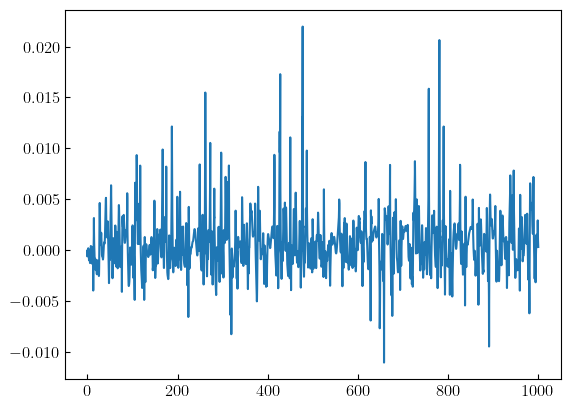

In [14]:
plt.plot(mrgsav_etdms_solver_vs.tn[1:],  np.diff(mrgsav_etdms_solver_vs.Enstrophy))